# Summary
This notebook implements a small Multi-Layer Perceptron (MLP) from scratch using NumPy and trains it on a toy binary classification dataset.


## Binary cross-entropy loss
For binary classification, the model outputs a logit $z$. We convert it to a probability with the sigmoid function and optimize the binary cross-entropy loss.


In [1]:
# uncomment if the following packages are not installed
# pip install numpy matplotlib


## Imports
We use NumPy for numerical computations and Matplotlib for plotting.


In [2]:
import numpy as np
import matplotlib.pyplot as plt


## BCE and ReLU classes
The `BCE` class computes the binary cross-entropy loss and its gradient. The `ReLU` class implements the activation used between linear layers.


In [3]:
class BCE:
    def __init__(self):
        pass

    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, z, y):
        """
        z shape: (N, 1) where N is the number of datapoints
        y shape: (N, 1)
        Returns:
            loss (scalar), prediction y_hat (N, 1)
        """
        y_hat = self.sigmoid(z)
        y_hat = np.clip(y_hat, 1e-12, 1 - 1e-12)  # avoid log(0)

        N = len(y)
        loss = - (1.0 / N) * np.sum(
            y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)
        )
        return loss, y_hat

    def backward(self, y_hat, y):
        """
        dL/dZ = (y_hat - y) / N
        Returns:
            dZ shape: (N, 1)
        """
        N = len(y)
        return (y_hat - y) / N


class ReLU:
    def __init__(self):
        self.requires_grad = False  # ReLU has no trainable parameters

    def forward(self, Z):
        """
        Z shape: (N, d_out) or any shape
        """
        self.Z = Z  # save for backward
        return np.maximum(0, Z)

    def backward(self, dA):
        """
        dA shape: same as Z
        dZ = dA * (Z > 0)
        """
        dZ = dA * (self.Z > 0).astype(float)
        return dZ


## Linear layer
A linear layer applies $XW + b$ during the forward pass and stores the gradients of $W$ and $b$ during the backward pass.


In [4]:
class LinearLayer:
    def __init__(self, d_in, d_out):
        self.requires_grad = True
        self.W = np.random.randn(d_in, d_out) / np.sqrt((d_in + d_out) / 2.0)
        self.b = np.zeros(d_out)

    def forward(self, X):
        """
        X shape: (N, d_in)
        W shape: (d_in, d_out)
        b shape: (d_out,)
        output shape: (N, d_out)
        """
        self.X = X  # save input for backward
        out = X @ self.W + self.b
        return out

    def backward(self, dZ):
        """
        dZ shape: (N, d_out)
        dW shape: (d_in, d_out)
        db shape: (d_out,)
        dX shape: (N, d_in)
        """
        self.dW = self.X.T @ dZ
        self.db = np.sum(dZ, axis=0)
        dX = dZ @ self.W.T
        return dX


## MLP class
The MLP is a sequence of linear layers and activation functions. The final sigmoid is handled inside the BCE loss.


In [5]:
class MLP:
    """
    layer_dims: list of ints representing layer sizes.
    e.g., [d_in, 10, 5, d_out] gives a network with two hidden layers.
    act: activation function class, e.g. ReLU.
    """
    def __init__(self, layer_dims, act):
        num_layers = len(layer_dims) - 1
        self.layers = []

        for i in range(num_layers):
            self.layers.append(LinearLayer(layer_dims[i], layer_dims[i + 1]))

            if i < num_layers - 1:
                self.layers.append(act())

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, dlogits):
        dZ = dlogits
        for layer in reversed(self.layers):
            dZ = layer.backward(dZ)


## Gradient descent optimizer
This optimizer updates every trainable layer using its stored gradients.


In [6]:
class GD:
    def __init__(self, lr=1e-3, weight_decay=0.0):
        self.lr = lr
        self.weight_decay = weight_decay

    def step(self, model):
        for layer in model.layers:
            if layer.requires_grad:
                layer.W = layer.W - self.lr * (layer.dW + self.weight_decay * layer.W)
                layer.b = layer.b - self.lr * layer.db


## Create an artificial 2D dataset
We sample two classes from different Gaussian distributions and combine them into one binary classification dataset.


In [7]:
np.random.seed(0)

num_samples = 1000

# Class 0: Gaussian centered at (2, 2)
mean0 = [2, 2]
cov0 = [[2, 1], [1, 2]]
data0 = np.random.multivariate_normal(mean0, cov0, num_samples)
labels0 = np.zeros(num_samples)

# Class 1: Gaussian centered at (-1, -1)
mean1 = [-1, -1]
cov1 = [[2, -1], [-1, 2]]
data1 = np.random.multivariate_normal(mean1, cov1, num_samples)
labels1 = np.ones(num_samples)

X = np.vstack((data0, data1))
y = np.hstack((labels0, labels1)).reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2000, 2)
y shape: (2000, 1)


## Plot the data
This plot shows the two Gaussian clusters that the MLP will learn to separate.


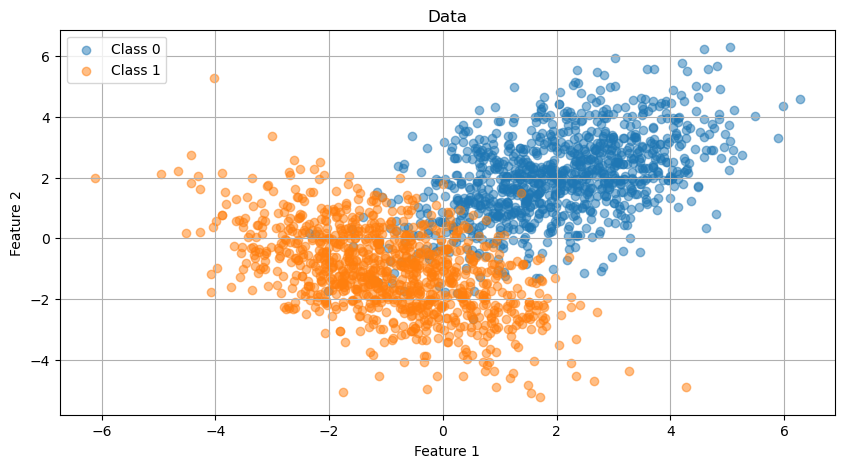

In [8]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

plt.figure(figsize=(10, 5))
plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], label="Class 0", alpha=0.5)
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], label="Class 1", alpha=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Data")
plt.legend()
plt.grid(True)
plt.show()


## Training loop
We repeatedly run a forward pass, compute the BCE loss, backpropagate gradients, and update the model parameters.


In [9]:
np.random.seed(0)

model = MLP(layer_dims=[2, 200, 200, 1], act=ReLU)
loss_fn = BCE()
optim = GD(lr=5e-1)

losses = []
accs = []
num_iter = 500

for i in range(num_iter):
    Z = model.forward(X)
    loss, y_hat = loss_fn.forward(Z, y)

    losses.append(loss)
    accs.append(np.mean((y_hat > 0.5).astype(int) == y))

    dZ = loss_fn.backward(y_hat, y)
    model.backward(dZ)
    optim.step(model)

print(f"Final loss: {losses[-1]:.4f}")
print(f"Final accuracy: {accs[-1]:.4f}")


Final loss: 0.1298
Final accuracy: 0.9505


## Plot training loss and accuracy
The loss should decrease and the accuracy should increase as training progresses.


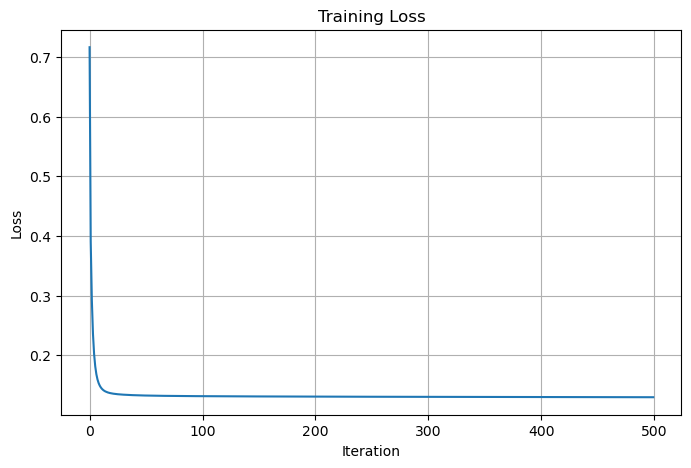

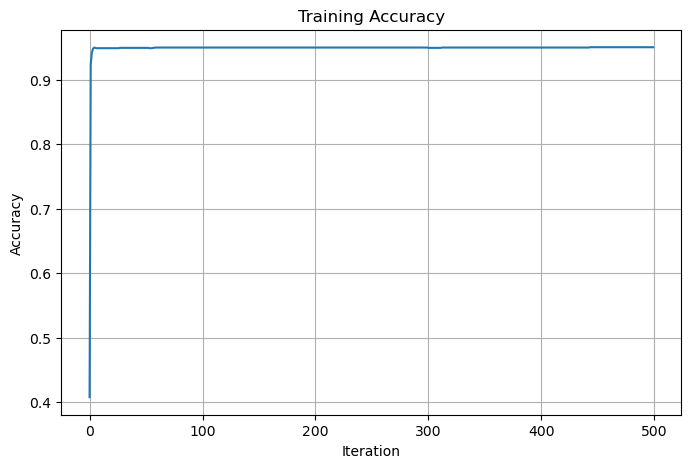

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(accs)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.show()


## Plot neural network predictions
Finally, we color each datapoint according to the model prediction after training.


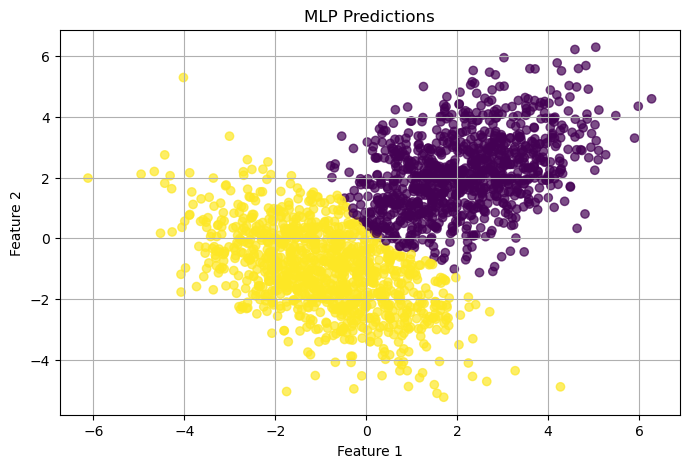

In [11]:
Z = model.forward(X)
loss, y_hat = loss_fn.forward(Z, y)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=(y_hat > 0.5).astype(int), alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("MLP Predictions")
plt.grid(True)
plt.show()


## Optional: plot the decision boundary
This evaluates the trained MLP on a grid to visualize the learned classifier.


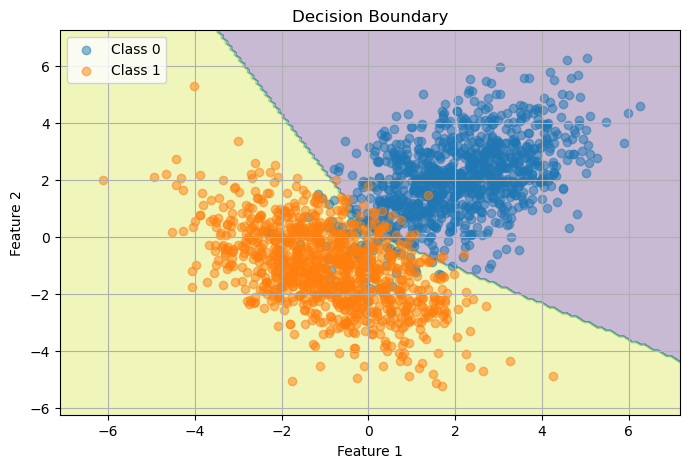

In [12]:
grid = np.c_[xx.ravel(), yy.ravel()]
Z_grid = model.forward(grid)
_, y_grid = loss_fn.forward(Z_grid, np.zeros((len(grid), 1)))
y_grid = y_grid.reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, y_grid > 0.5, alpha=0.3)
plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], label="Class 0", alpha=0.5)
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], label="Class 1", alpha=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()
